In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, FunctionTransformer, PolynomialFeatures, RobustScaler
from sklearn.linear_model import LinearRegression, Ridge
import os
import fiona

In [2]:
meteo_doubs = gpd.read_file("../datasets_par_departement/meteo_doubs.geojson")

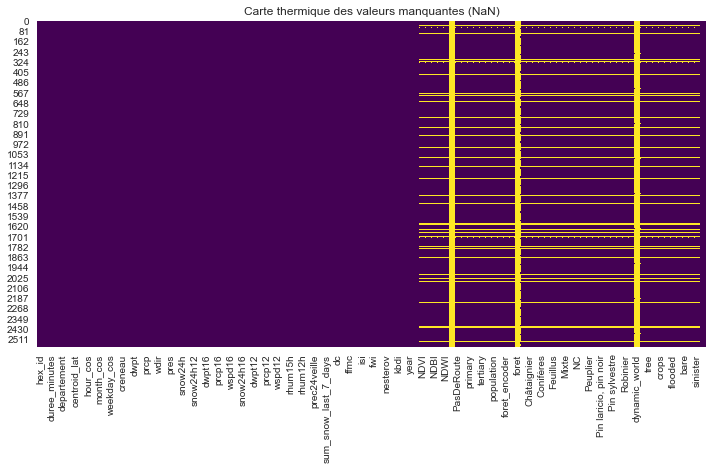

In [3]:
plt.figure(figsize=(12, 6))
sns.heatmap(meteo_doubs.isnull(), cbar=False, cmap='viridis')
plt.title("Carte thermique des valeurs manquantes (NaN)")
plt.show()

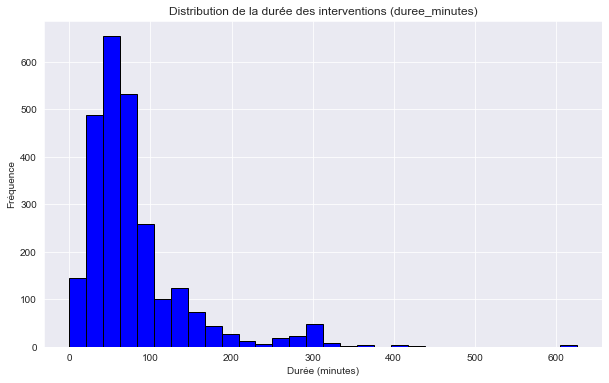

In [4]:
plt.figure(figsize=(10, 6))
plt.hist(meteo_doubs['duree_minutes'], bins=30, color='blue', edgecolor='black')
plt.title("Distribution de la durée des interventions (duree_minutes)")
plt.xlabel("Durée (minutes)")
plt.ylabel("Fréquence")
plt.show()

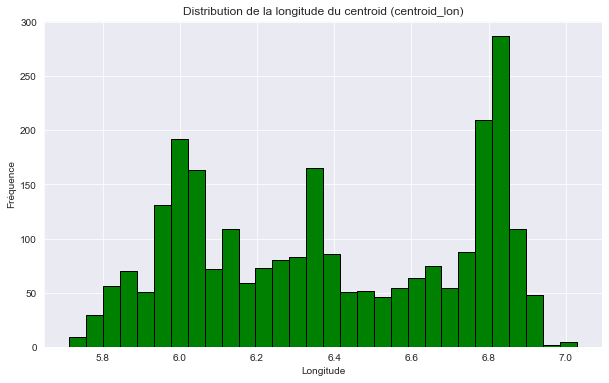

In [5]:
plt.figure(figsize=(10, 6))
plt.hist(meteo_doubs['centroid_lon'], bins=30, color='green', edgecolor='black')
plt.title("Distribution de la longitude du centroid (centroid_lon)")
plt.xlabel("Longitude")
plt.ylabel("Fréquence")
plt.show()

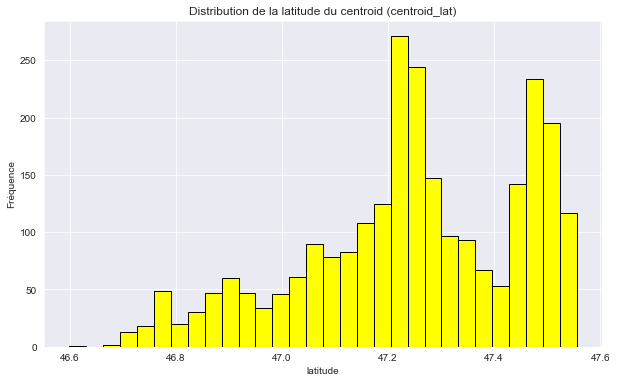

In [6]:
plt.figure(figsize=(10, 6))
plt.hist(meteo_doubs['centroid_lat'], bins=30, color='yellow', edgecolor='black')
plt.title("Distribution de la latitude du centroid (centroid_lat)")
plt.xlabel("latitude")
plt.ylabel("Fréquence")
plt.show()

In [7]:
meteo_doubs.columns

Index(['hex_id', 'id_meteo', 'duree_minutes', 'date', 'departement',
       'centroid_lon', 'centroid_lat', 'hour_sin', 'hour_cos', 'month_sin',
       ...
       'tree', 'grass', 'crops', 'shrub', 'flooded', 'built', 'bare', 'snow_y',
       'sinister', 'geometry'],
      dtype='object', length=112)

In [8]:
X = meteo_doubs.drop(columns=['duree_minutes', 'geometry', 'hex_id', 'id_meteo', 'index', 'creneau', 'date', 'departement'])
y = meteo_doubs['duree_minutes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_scaled, y_train)

y_pred = ridge_model.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"RMSE : {rmse}")
print(f"R² : {r2}")

/Users/silarbinunzio/opt/anaconda3/lib/python3.8/site-packages/sklearn/utils/extmath.py:1050: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/Users/silarbinunzio/opt/anaconda3/lib/python3.8/site-packages/sklearn/utils/extmath.py:1055: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/Users/silarbinunzio/opt/anaconda3/lib/python3.8/site-packages/sklearn/utils/extmath.py:1075: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


ValueError: Input X contains NaN.
Ridge does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

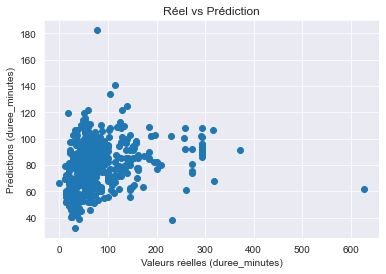

In [12]:
plt.scatter(y_test, y_pred)
plt.xlabel('Valeurs réelles (duree_minutes)')
plt.ylabel('Prédictions (duree_minutes)')
plt.title('Réel vs Prédiction')
plt.show()

In [15]:
percentile_90 = meteo_doubs['duree_minutes'].quantile(0.90)

filtered_data = meteo_doubs[meteo_doubs['duree_minutes'] <= percentile_90]

print(f"Dimensions originales : {meteo_doubs.shape}")
print(f"Dimensions après suppression des 10 % les plus hauts : {filtered_data.shape}")

Dimensions originales : (2572, 64)
Dimensions après suppression des 10 % les plus hauts : (2319, 64)


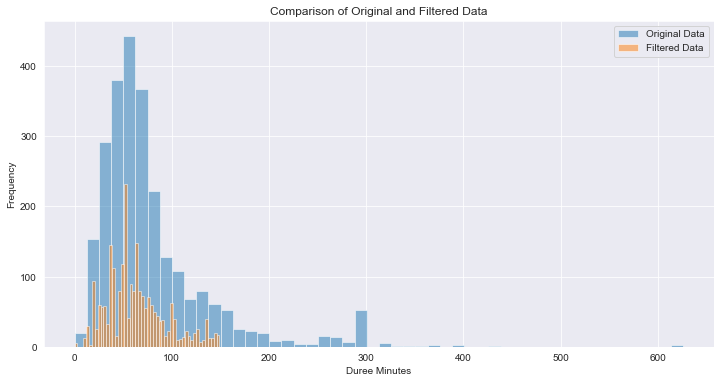

In [17]:
plt.figure(figsize=(12, 6))
plt.hist(meteo_doubs['duree_minutes'], bins=50, alpha=0.5, label='Original Data')
plt.hist(filtered_data['duree_minutes'], bins=50, alpha=0.5, label='Filtered Data')
plt.xlabel('Duree Minutes')
plt.ylabel('Frequency')
plt.legend()
plt.title('Comparison of Original and Filtered Data')
plt.show()

In [22]:
X_filtered = filtered_data.drop(columns=['duree_minutes', 'geometry', 'hex_id', 'id_meteo', 'index', 'creneau', 'date', 'departement'])
y_filtered = filtered_data['duree_minutes']

X_train, X_test, y_train, y_test = train_test_split(X_filtered, y_filtered, test_size=0.2, random_state=42)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred = ridge.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE (Mean Absolute Error) : {mae:.2f} minutes")
print(f"MSE (Mean Squared Error) : {mse:.2f}")
print(f"R² (Coefficient of Determination) : {r2:.2f}")

MAE (Mean Absolute Error) : 22.69 minutes
MSE (Mean Squared Error) : 845.32
R² (Coefficient of Determination) : 0.08
